# Claris – VGG16_BN Model

## Model

The model used in this project is VGG16_BN with ImageNetV1 transfer learning implemented. The model's output layer consists of two neurons: benign or malignant.

## Implementation

This implementation utilizes PyTorch. The model is trained on Kaggle duo-T4 GPU.
  
## Accuracy
**~97.39%** peak accuracy after 15 epochs.


### 1) Imports and configuration

In [25]:
# Import useful libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

#### Setting up the environment
Using Kaggle's Nvidia GPU 

In [26]:
# Device -> Nvidia GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU cuda if available
print('Using device:', DEVICE)

# Config
IMG_SIZE = 96
BATCH_SIZE = 64
NUM_WORKERS = 4


Using device: cuda


### 2) Data transformations
Diversify the training data by augmenting the images with random rotations, flips, and translations.

In [27]:
# Train data transformations
#  - Augmented to increase diversity of the dataset
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),            # Ensure consistent size
    transforms.RandomHorizontalFlip(),                  # Random flips (augmentation)
    transforms.RandomVerticalFlip(),                    # Random flips  (augmentation)
    transforms.RandomRotation(20),                      # Random rotations (augmentation)
    transforms.ToTensor(),                              # Convert to tensor
    transforms.Normalize(                               # Standardize pixel values
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# Test data transformations (no augmentation or randomness)
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 3) Data loading helper class


In [28]:
class Dataset(Dataset):
    """
    Dataset for Kaggle Histopathologic Cancer Detection (based on PCAM)
    Uses .tif images + train_labels.csv
    """

    def __init__(self, img_dir, csv_path, transform=None):
        self.img_dir = img_dir
        self.transform = transform
    
        self.df = pd.read_csv(csv_path) # train_labels.csv

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]          # image id
        label  = int(self.df.iloc[idx, 1])     # 0 or 1 (cancer or not)

        # Load image and convert pixel data to RGB values
        img_path = os.path.join(self.img_dir, img_id + ".tif")
        image = Image.open(img_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label


### 4) Load PCam dataset


In [29]:
# Kaggle directory (PCam)
BASE_DIR = "/kaggle/input/competitions/histopathologic-cancer-detection/"

TRAIN_DIR = BASE_DIR + "train"
CSV_PATH = BASE_DIR + "train_labels.csv"

# Read in the CSV file
df = pd.read_csv(CSV_PATH)

# Split into train and validation datasets
train_df, val_df = train_test_split(
    df,
    test_size=0.2,          # 20% of the data will be used for validation
    stratify=df["label"],   # Ensure that the validation set has similar distribution to the training set
    random_state=42
)

# Save the split datasets to CSV files
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)


#### Data loaders


In [30]:

BATCH_SIZE = 128

train_dataset = Dataset(
    TRAIN_DIR, "train_split.csv", train_tfms
)

val_dataset = Dataset(
    TRAIN_DIR, "val_split.csv", val_tfms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True, # faster GPU data transfer
    persistent_workers=True, # keep warm state for >1 epoch
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    persistent_workers=True,
    num_workers=NUM_WORKERS
)

### 5) Loading VGG-16 model
The model has been pre-trained on ImageNet. <br>
Hence, the model already knows how to detect edges, textures, patterns, colors, etc.


In [31]:
# Load pretrained VGG16_BN from torchvision
model = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1)

# Replace the classifier layer
num_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(num_features, 2)

# Wrap for multi-GPU
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model) # parallel computing
    
model = model.to(DEVICE)

# If model exists, load it
if os.path.exists("./claris_vgg16_bn.pth"):
    model.load_state_dict(torch.load("./claris_vgg16_bn.pth"))
    print(f"Successfully loaded saved model VGG16_BN")
else:
    print("No saved model found. Training from scratch.")


Using 2 GPUs!
No saved model found. Training from scratch.


#### Loss function and optimizer

In [32]:
# Class imbalance handling
class_weights = torch.tensor([1.0, 1.5]).to(DEVICE)

# Binary classification
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Prevent underflow (~0 gradient rounded to 0)
scaler = torch.amp.GradScaler() 

### 6) Training the model!

In [33]:
def train_one_epoch(model, loader):
    
    model.train()  # enable training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    loop = tqdm(loader, total=len(train_loader), desc="Training")

    for images, labels in loop:
        # Move data to device (GPU)
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # Reset gradients
        optimizer.zero_grad()
        
        # Mixed precision training for faster training
        # COMPARE RESULTS AND PENALIZE LOSS
        with torch.amp.autocast("cuda"):
            # Forward pass (prediction results)
            outputs = model(images)
            # Compute loss
            loss = criterion(outputs, labels)

        # Backpropagation (how should each weight change to make the loss smaller?)
        scaler.scale(loss).backward() # loss.backward()

        # Update weights for real
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        
        # Compute accuracy
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        train_acc = correct / total
        
        # Update progress bar
        loop.set_postfix(loss=running_loss / (loop.n+1))
        
    print(f"Trained {correct} correct out of {total}")

    return running_loss / len(loader), train_acc


#### Validation

In [34]:
def validate(model, loader):
    model.eval()  # evaluation mode
    correct = 0
    total = 0
    
    # Lists to store all predicitons and actual labels for the entire epoch
    all_predictions = []
    all_labels = []

    # Disable gradients in inference mode
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False): # Progress bar
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Keep track of the total number of correct predictions and total predictions
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            # Move tensors back to CPU and add to our lists
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Calculate metrics
    acc = accuracy_score(all_labels, all_predictions)
    prec = precision_score(all_labels, all_predictions, zero_division=0)
    rec = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    cm = confusion_matrix(all_labels, all_predictions)

    # Print out the results
    print(f"Validation -> Acc: {acc*100:.2f}% | Precision: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1: {f1:.4f}")
    
    # Plot the Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign (0)', 'Malignant (1)'], 
                yticklabels=['Benign (0)', 'Malignant (1)'])
    plt.ylabel('Réelle')
    plt.xlabel('Prédite')
    plt.title('Matrice de confusion')
    plt.show()

    return acc



### 7) Visualizing prediction results


In [35]:
# Plotting for visualization

def plot_validation_accuracy(val_history):
    epochs = range(1, len(val_history) + 1)
    
    plt.figure(figsize=(10, 6))
    # Plot only the validation data
    plt.plot(epochs, val_history, marker='s', linestyle='-', color='r', label='Exactitude de validation')
    
    plt.title("Évolution de l'exactitude de VGG16_BN en fonction des epochs (Validation)")
    plt.xlabel('Epochs')
    plt.ylabel('Exactitude (%)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    
def plot_training_accuracy(train_history):
    epochs = range(1, len(train_history) + 1)
    
    plt.figure(figsize=(10, 6))
    # Plot only the training data
    plt.plot(epochs, train_history, marker='s', linestyle='-', color='b', label='Exactitude d\'entraînement')
    
    plt.title("Évolution de l'exactitude de VGG16_BN en fonction des epochs (Entraînement)")
    plt.xlabel('Epochs')
    plt.ylabel('Exactitude (%)')
    plt.legend()
    plt.grid(True)
    plt.show()



Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 162675 correct out of 176020


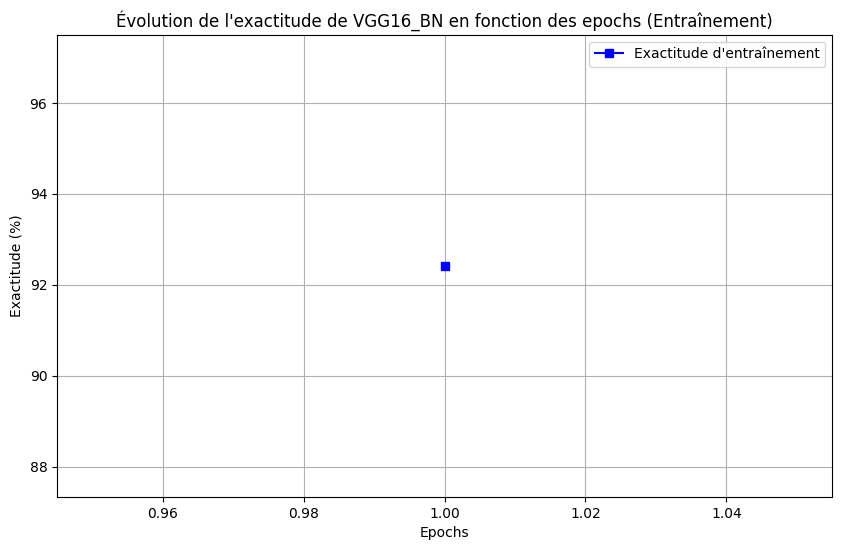

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 95.46% | Precision: 94.40% | Recall: 94.38% | F1: 0.9439


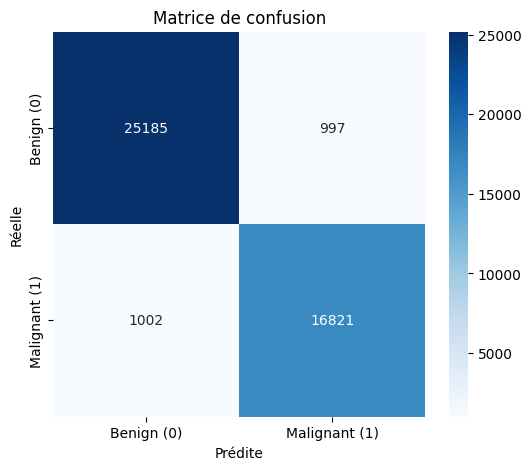

Epoch [1/15] Train Loss: 0.1984 | Train Acc: 92.42% | Val Acc: 95.46% 


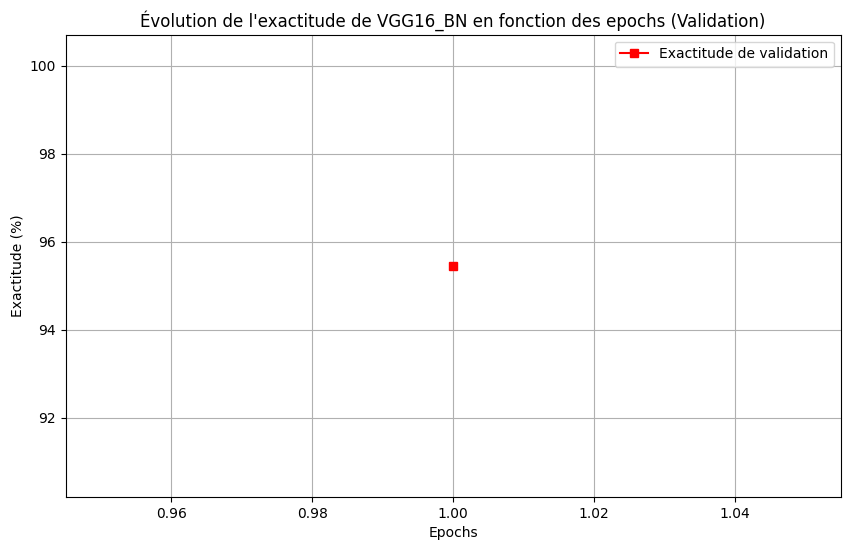

✓ Model saved with 95.46% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a41e65e4fe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a41e65e4fe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Trained 167167 correct out of 176020


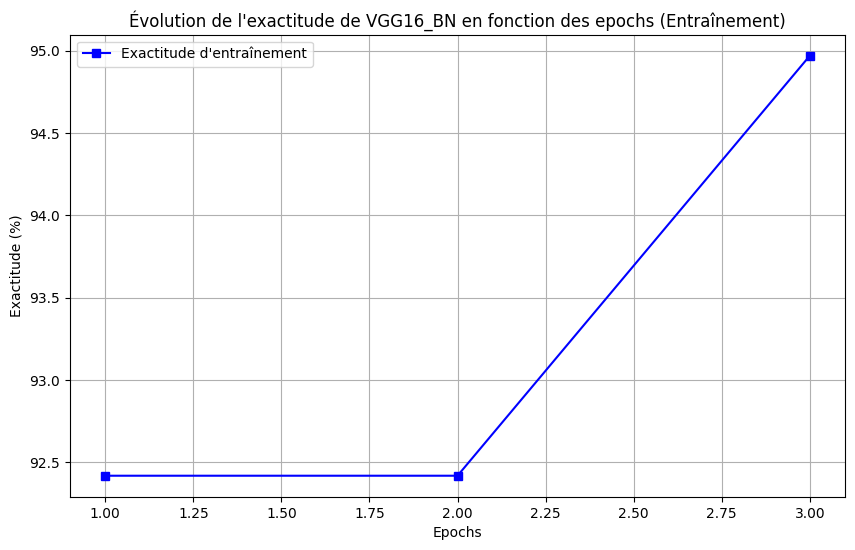

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.00% | Precision: 96.05% | Recall: 93.97% | F1: 0.9500


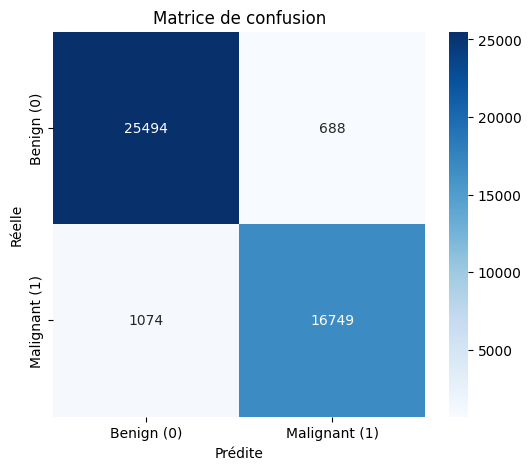

Epoch [2/15] Train Loss: 0.1402 | Train Acc: 94.97% | Val Acc: 96.00% 


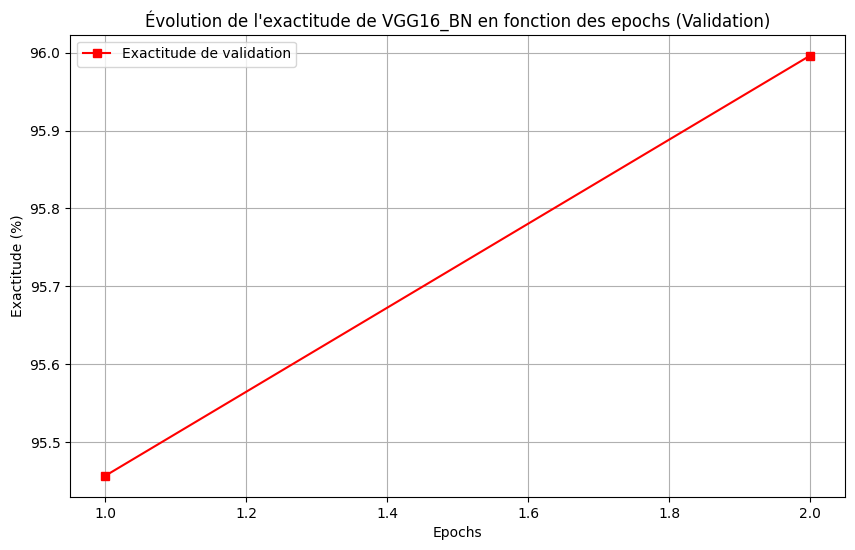

✓ Model saved with 96.00% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 168665 correct out of 176020


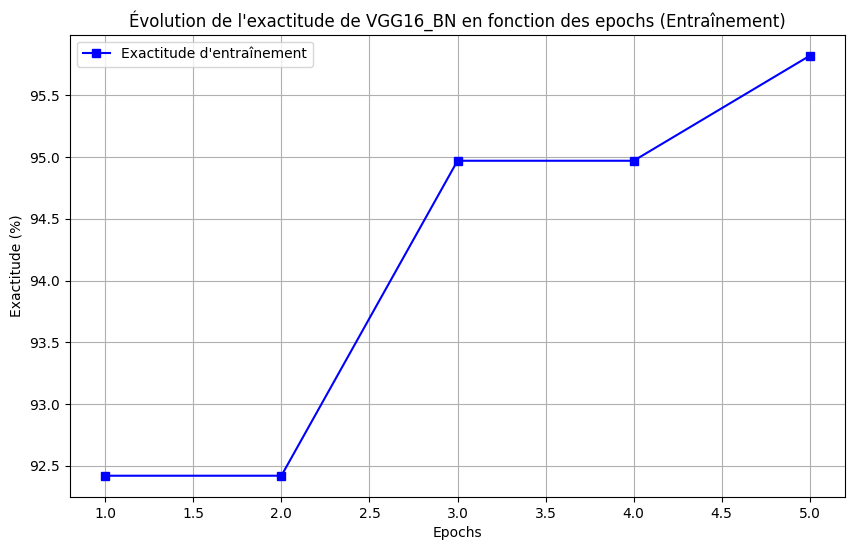

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.23% | Precision: 93.94% | Recall: 96.95% | F1: 0.9542


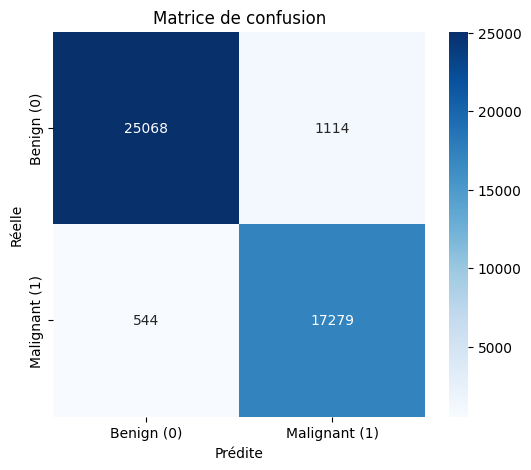

Epoch [3/15] Train Loss: 0.1190 | Train Acc: 95.82% | Val Acc: 96.23% 


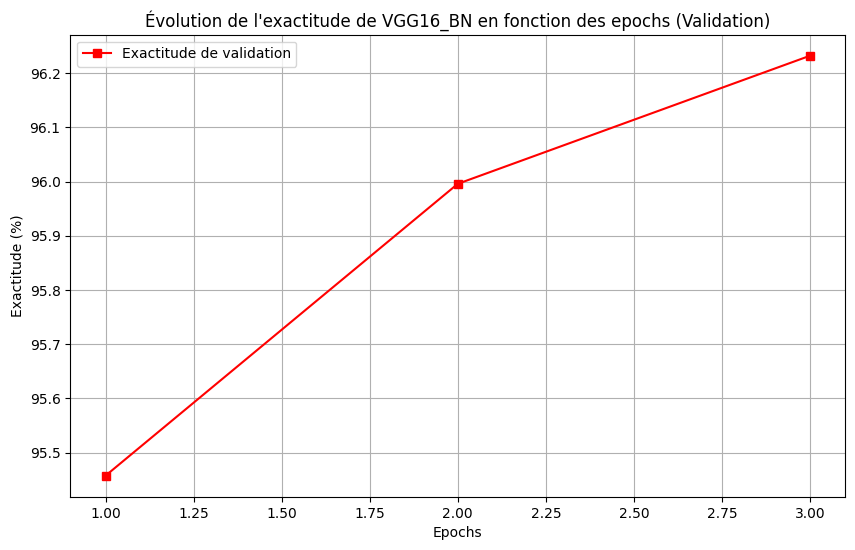

✓ Model saved with 96.23% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 169519 correct out of 176020


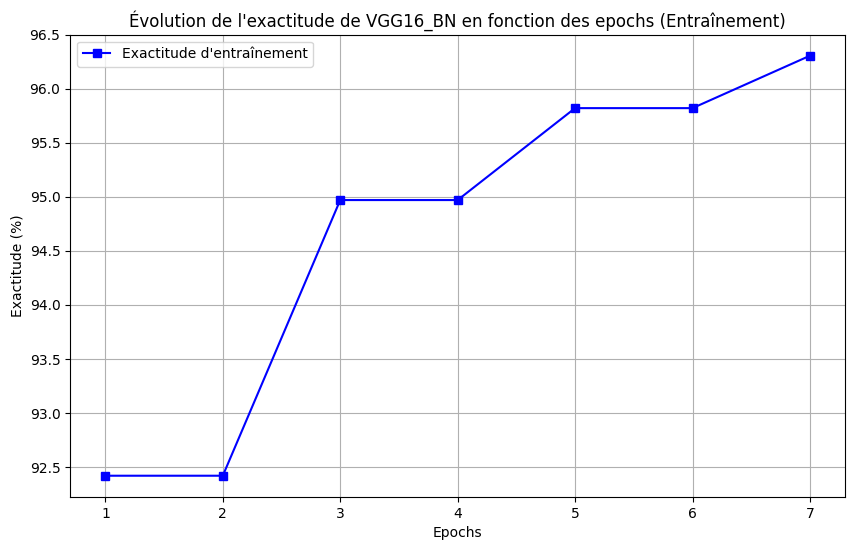

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.80% | Precision: 95.53% | Recall: 96.62% | F1: 0.9607


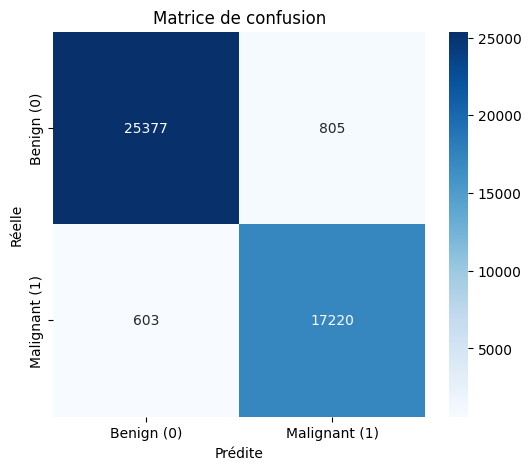

Epoch [4/15] Train Loss: 0.1064 | Train Acc: 96.31% | Val Acc: 96.80% 


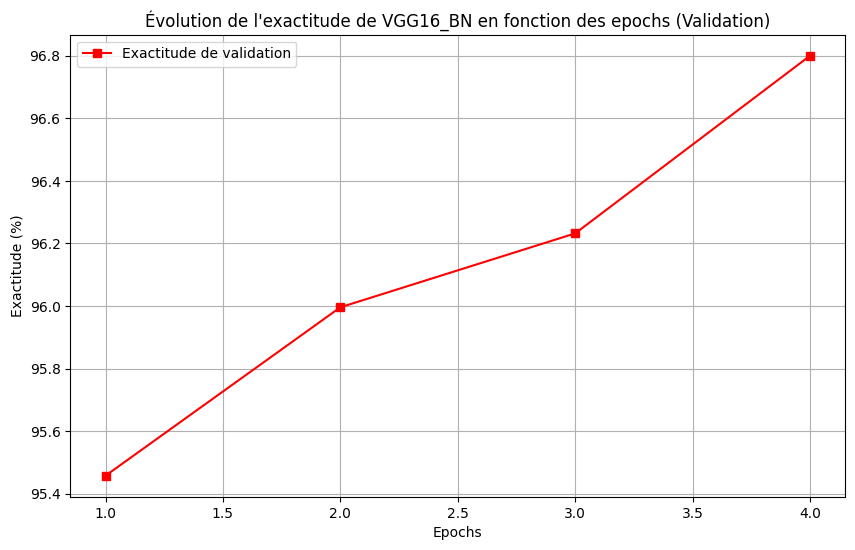

✓ Model saved with 96.80% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 170066 correct out of 176020


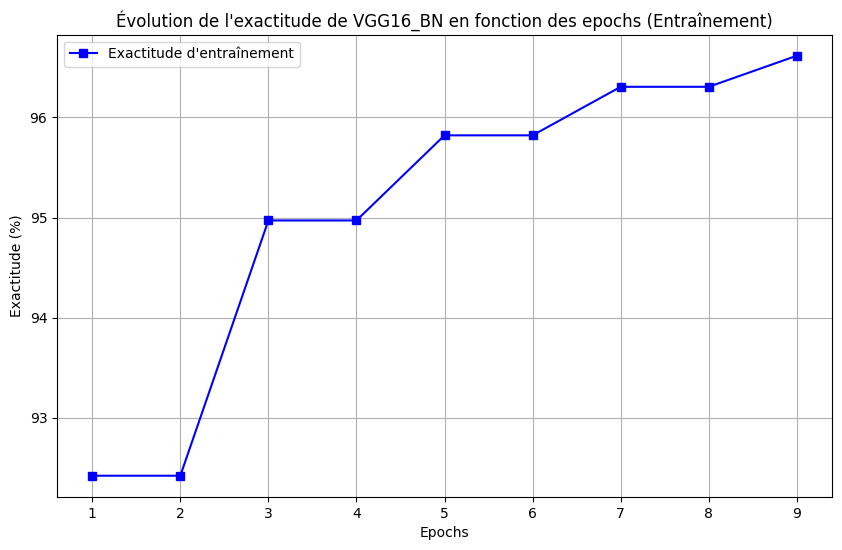

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.62% | Precision: 94.18% | Recall: 97.68% | F1: 0.9590


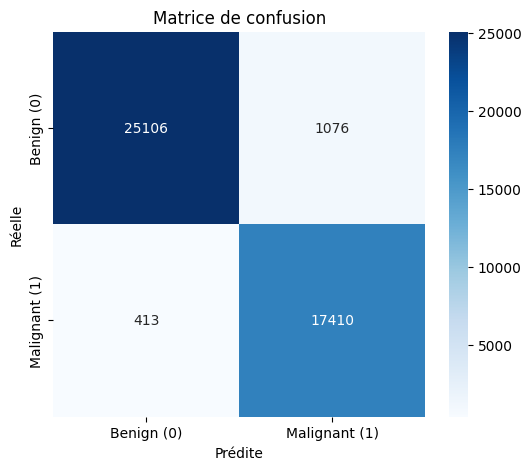

Epoch [5/15] Train Loss: 0.0974 | Train Acc: 96.62% | Val Acc: 96.62% 


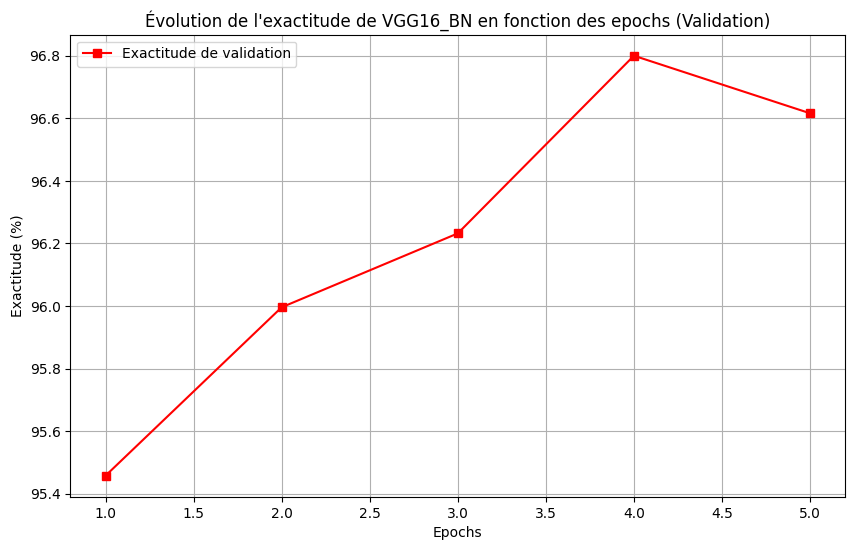

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 170524 correct out of 176020


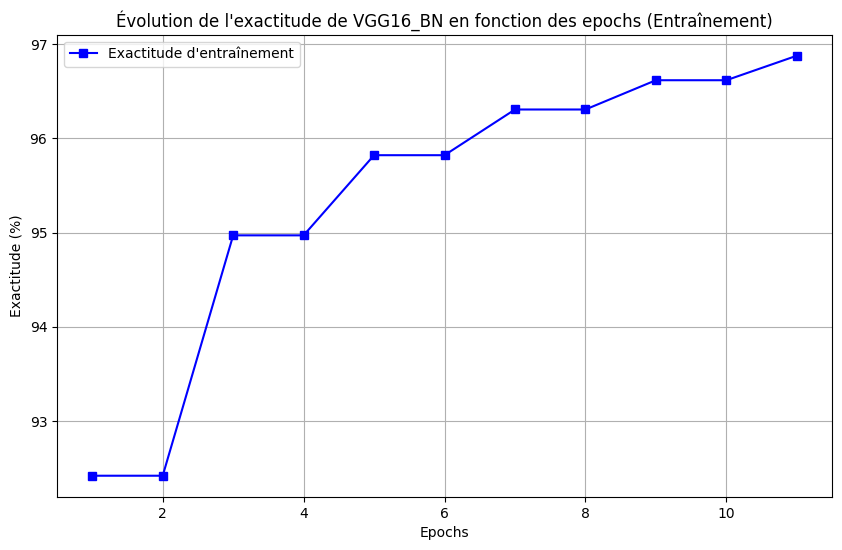

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.08% | Precision: 95.15% | Recall: 97.78% | F1: 0.9644


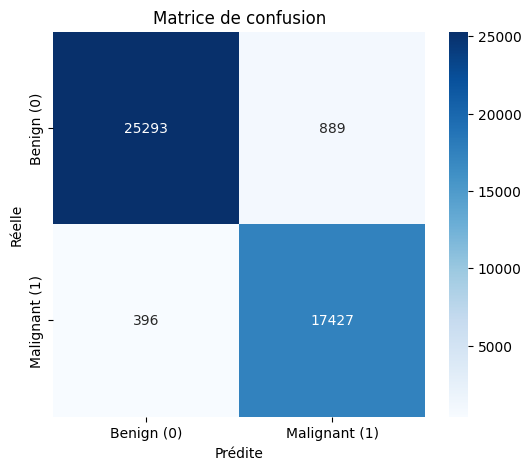

Epoch [6/15] Train Loss: 0.0907 | Train Acc: 96.88% | Val Acc: 97.08% 


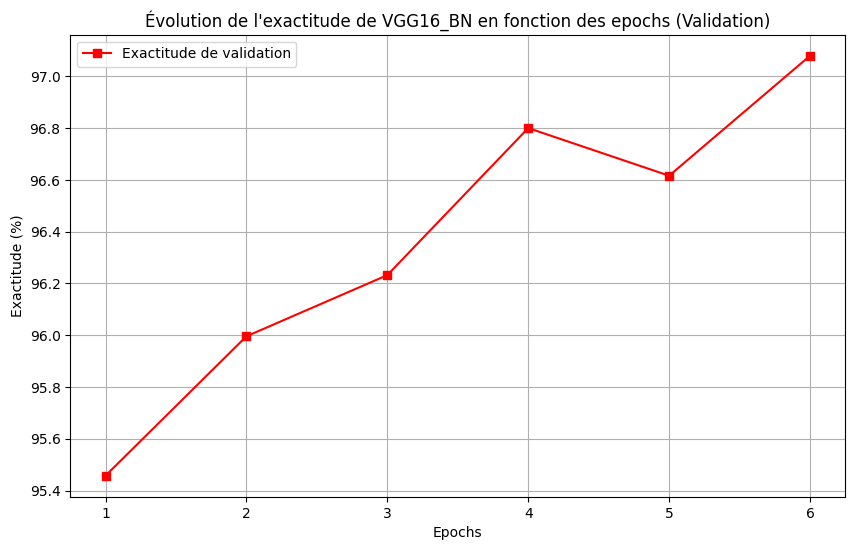

✓ Model saved with 97.08% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 170819 correct out of 176020


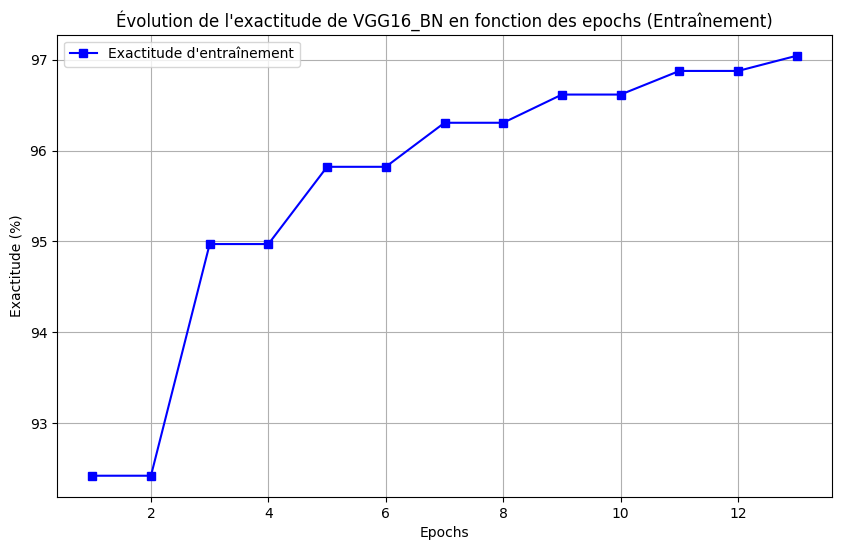

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.05% | Precision: 96.34% | Recall: 96.37% | F1: 0.9635


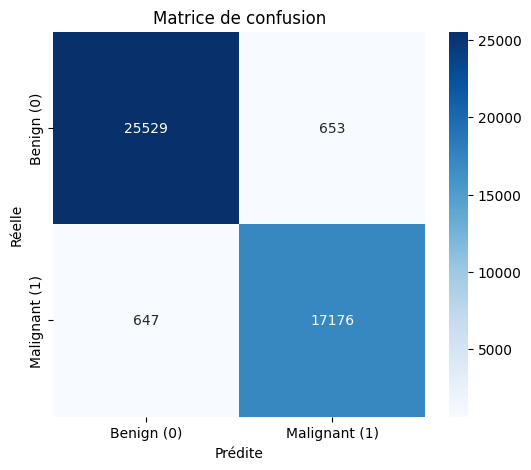

Epoch [7/15] Train Loss: 0.0857 | Train Acc: 97.05% | Val Acc: 97.05% 


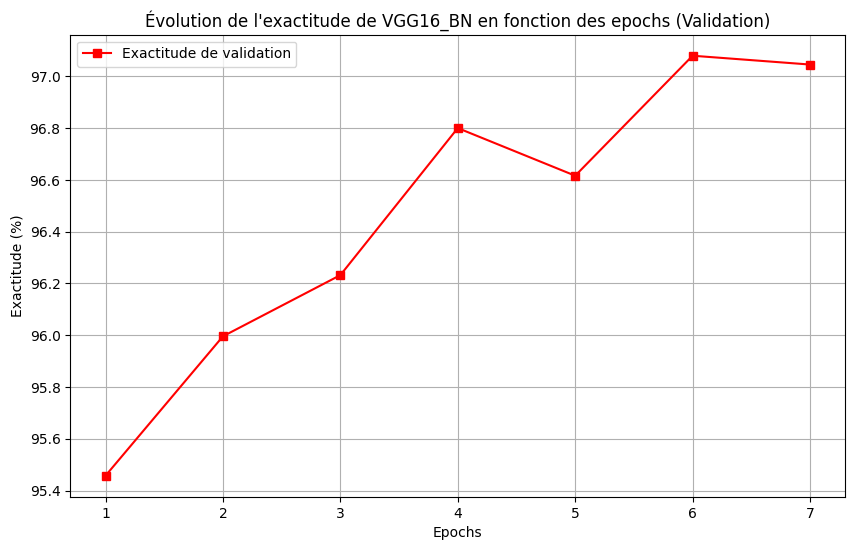

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 171217 correct out of 176020


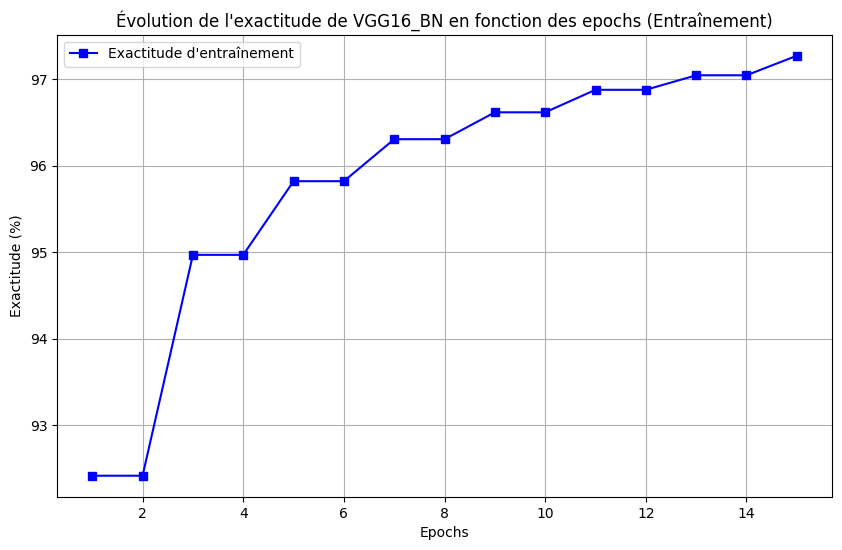

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.68% | Precision: 96.70% | Recall: 97.60% | F1: 0.9715


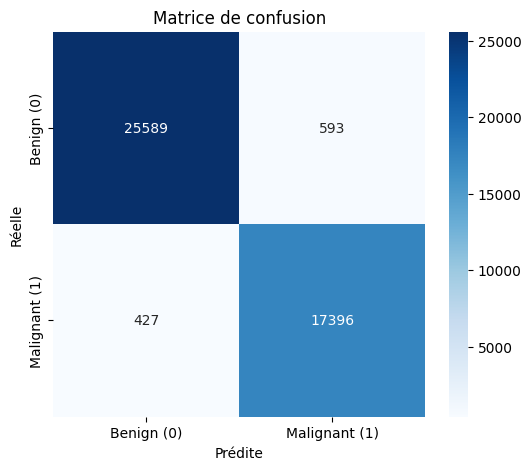

Epoch [8/15] Train Loss: 0.0797 | Train Acc: 97.27% | Val Acc: 97.68% 


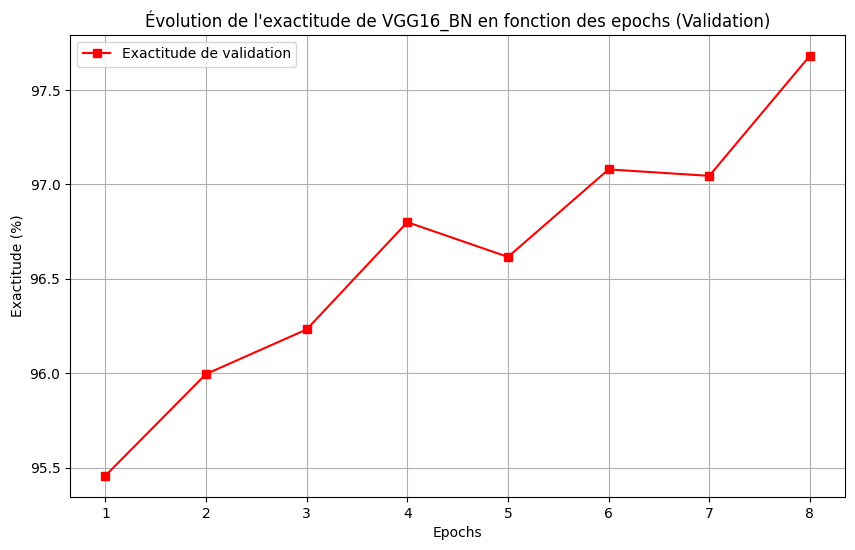

✓ Model saved with 97.68% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 171505 correct out of 176020


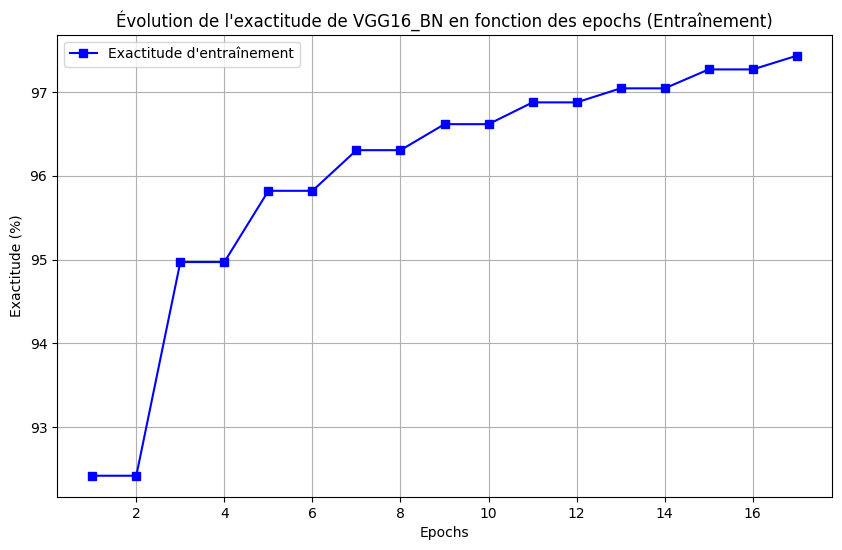

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.44% | Precision: 96.33% | Recall: 97.39% | F1: 0.9686


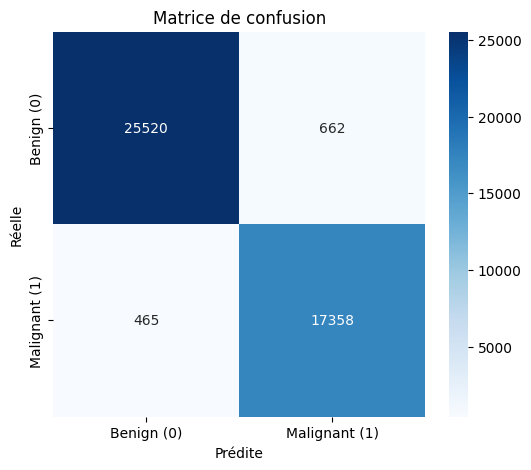

Epoch [9/15] Train Loss: 0.0753 | Train Acc: 97.43% | Val Acc: 97.44% 


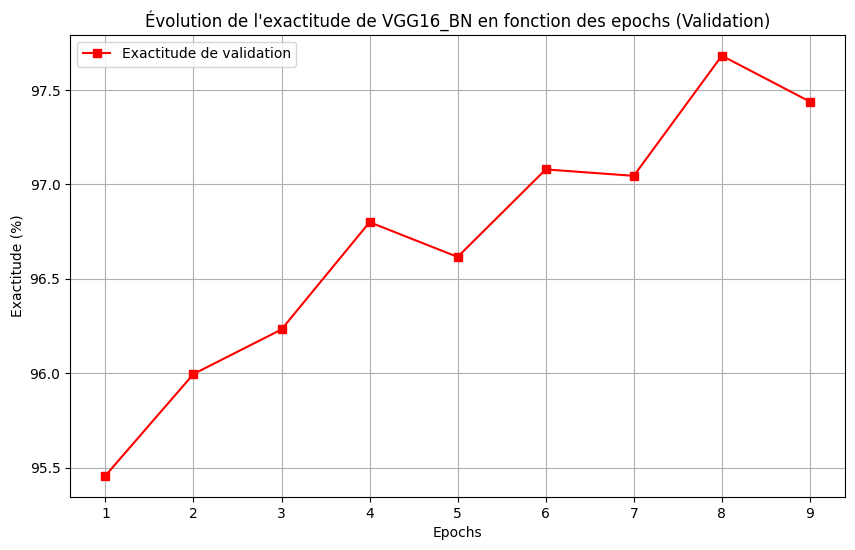

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 171718 correct out of 176020


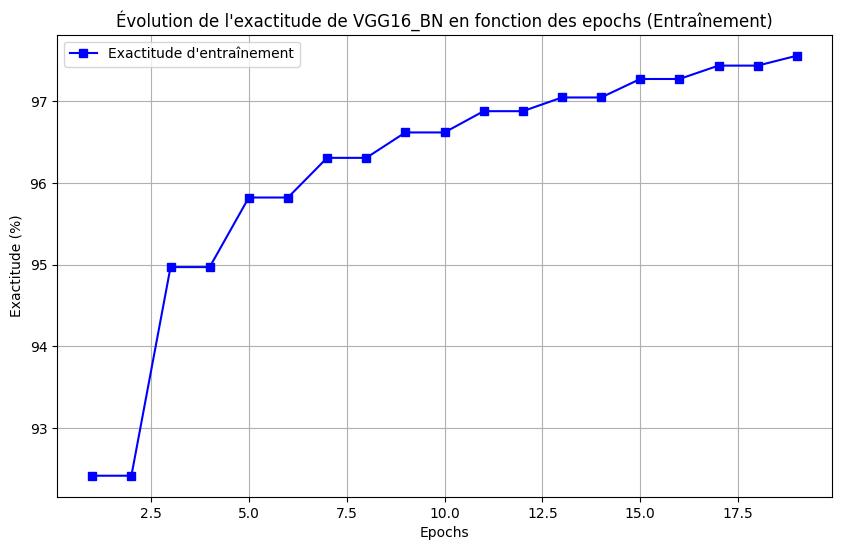

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.64% | Precision: 96.78% | Recall: 97.40% | F1: 0.9709


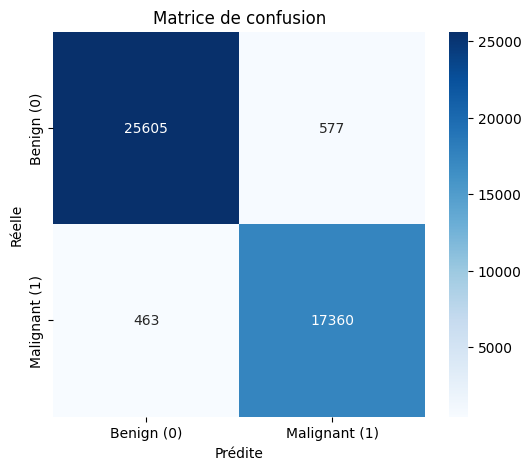

Epoch [10/15] Train Loss: 0.0713 | Train Acc: 97.56% | Val Acc: 97.64% 


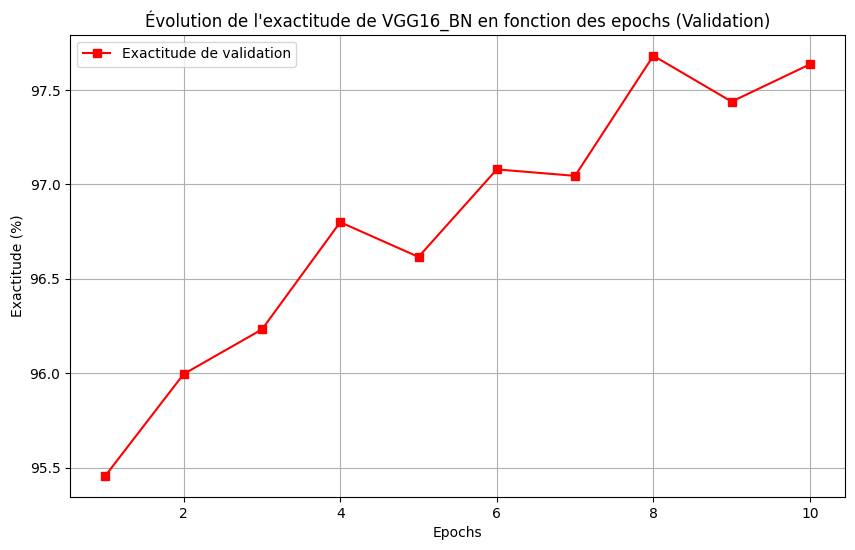

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [36]:
EPOCHS = 15  # increase later

train_acc_history = []
val_acc_history = []
best_val_acc = 0

for epoch in range(EPOCHS):
      
    train_loss, train_acc = train_one_epoch(model, train_loader)
    # Display training graph
    train_acc_history.append(train_acc * 100)
    plot_training_accuracy(train_acc_history)

    val_acc = validate(model, val_loader)
    
    # Save history for accuracy graph
    train_acc_history.append(train_acc * 100)
    val_acc_history.append(val_acc * 100)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Val Acc: {val_acc*100:.2f}% ")
    
    # Display validation graph
    plot_validation_accuracy(val_acc_history)
    
    # Save model only if validation accuracy improves
    if val_acc > best_val_acc:
          best_val_acc = val_acc
          torch.save(model.state_dict(), "./claris_vgg16_bn.pth")
          print(f"✓ Model saved with {val_acc*100:.2f}% accuracy")
